# LangGraph + RAG + LangSmith
- LangSmith란?
    - Graph가 내부에서 정확히 어떻게 움직이는지, 어디서 시간이 오래 걸리는지, 도구가 몇 번 호출됐는지, 토큰이 얼마나 들었는지 등을 실시간으로 시각화해 줍니다. 
    - print()로 디버깅하는 대신, LangSmith 대시보드에서 Graph 실행 흐름을 한눈에 파악할 수 있습니다.
- LangSmith의 장점
    - 코드 수정 없이 모든 정보 자동 추적
    - 시각적 UI로 실행 흐름 한눈에 파악
    - 토큰 사용량과 비용 자동 계산
    - 여러 실행 기록을 비교하며 개선 효과 확인

- LangSmith 회원가입과 API Key 발급 필요
    - 회원가입: https://smith.langchain.com
    - API Key 발급 및 복사

- .env 추가 
    - LANGSMITH_API_KEY, 
    - LANGSMITH_TRACING=true, 
    - LANGSMITH_PROJECT="my_app" 설정

In [ ]:
# 필요한 패키지 설치

# %pip install langsmith

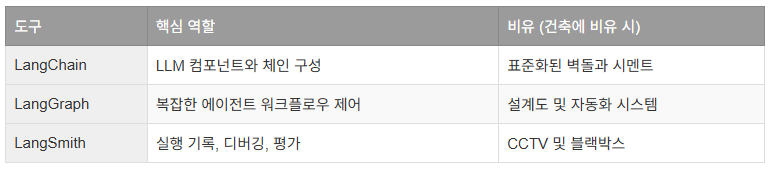

In [1]:
# ============================================================
# 1. 라이브러리
# ============================================================

from dotenv import load_dotenv
from typing import TypedDict, List

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma

from langgraph.graph import StateGraph, START, END

load_dotenv()

True

## 2. 샘플 문서

강의에서는 실제 PDF보다 짧은 메뉴 데이터를 사용하면  
Retriever → Generate → Trace 흐름을 쉽게 설명할 수 있습니다.

In [2]:
documents = [
    Document(
        page_content="""
        시그니처 스테이크는 국내산 한우 채끝을 사용합니다.
        가격은 45,000원이며,
        구운 채소와 레드와인 소스가 함께 제공됩니다.
        """,
        metadata={
            "category": "steak",
            "menu": "시그니처 스테이크"
        }
    ),

    Document(
        page_content="""
        트러플 크림 파스타는 생면 파스타와
        트러플 크림소스를 사용합니다.
        가격은 23,000원입니다.
        """,
        metadata={
            "category": "pasta",
            "menu": "트러플 크림 파스타"
        }
    ),

    Document(
        page_content="""
        해산물 토마토 파스타에는
        새우, 오징어, 홍합이 들어갑니다.
        가격은 21,000원입니다.
        """,
        metadata={
            "category": "pasta",
            "menu": "해산물 토마토 파스타"
        }
    ),

    Document(
        page_content="""
        리코타 치즈 샐러드는
        리코타 치즈와 신선한 채소,
        발사믹 드레싱으로 구성됩니다.
        가격은 16,000원입니다.
        """,
        metadata={
            "category": "salad",
            "menu": "리코타 치즈 샐러드"
        }
    ),
]

## 3. Embedding / Chroma / Retriever

In [3]:
embedding_model = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embedding_model,
    collection_name="restaurant_menu"
)

retriever = vectorstore.as_retriever(
    search_kwargs={"k": 2}
)

## 4. LLM과 Prompt

In [4]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
        당신은 레스토랑 메뉴 안내 AI입니다.

        반드시 제공된 Context를 이용해서
        사용자의 질문에 답변하세요.

        Context에 없는 정보는
        임의로 만들어내지 말고
        "메뉴 정보에서 확인할 수 없습니다."
        라고 답변하세요.

        Context:
        {context}
        """
    ),
    (
        "human",
        "{question}"
    )
])

## 5. LangGraph State 정의

In [5]:
class GraphState(TypedDict):
    question: str
    documents: List[Document]
    answer: str

## 6. retrieve Node

In [6]:
def retrieve(state: GraphState):
    print("\n========== RETRIEVE ==========")

    question = state["question"]
    print("질문 :", question)

    documents = retriever.invoke(question)

    print("\n검색 문서:")
    for i, doc in enumerate(documents, 1):
        print(f"\n--- 문서 {i} ---")
        print(doc.page_content)

    return {
        "documents": documents
    }

## 7. generate Node

In [7]:
def generate(state: GraphState):
    print("\n========== GENERATE ==========")

    question = state["question"]
    documents = state["documents"]

    context = "\n\n".join(
        doc.page_content
        for doc in documents
    )

    messages = prompt.invoke({
        "question": question,
        "context": context
    })

    response = llm.invoke(messages)

    print("\nAI 답변:")
    print(response.content)

    return {
        "answer": response.content
    }

## 8. LangGraph 구성

In [8]:
workflow = StateGraph(GraphState)

workflow.add_node("retrieve", retrieve)
workflow.add_node("generate", generate)

workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)

graph = workflow.compile()

## 9. LangGraph 실행

`.env`에 LangSmith 설정이 되어 있으면 이 실행 과정이 LangSmith에 Trace로 기록됩니다.

In [9]:
result = graph.invoke({
    "question": "시그니처 스테이크의 가격과 특징을 알려주세요.",
    "documents": [],
    "answer": ""
})

print("\n" + "=" * 60)
print("최종 답변")
print("=" * 60)
print(result["answer"])


========== RETRIEVE ==========
질문 : 시그니처 스테이크의 가격과 특징을 알려주세요.

검색 문서:

--- 문서 1 ---

        시그니처 스테이크는 국내산 한우 채끝을 사용합니다.
        가격은 45,000원이며,
        구운 채소와 레드와인 소스가 함께 제공됩니다.
        

--- 문서 2 ---

        리코타 치즈 샐러드는
        리코타 치즈와 신선한 채소,
        발사믹 드레싱으로 구성됩니다.
        가격은 16,000원입니다.
        

========== GENERATE ==========

AI 답변:
시그니처 스테이크는 국내산 한우 채끝을 사용하며, 가격은 45,000원입니다. 구운 채소와 레드와인 소스가 함께 제공됩니다.

최종 답변
시그니처 스테이크는 국내산 한우 채끝을 사용하며, 가격은 45,000원입니다. 구운 채소와 레드와인 소스가 함께 제공됩니다.


## 10. 여러 질문 실행

In [10]:
questions = [
    "시그니처 스테이크 가격은?",
    "트러플 크림 파스타 가격은?",
    "해산물 파스타에는 무엇이 들어가나요?",
    "리코타 치즈 샐러드의 특징은?",
    "피자 가격은 얼마인가요?"
]

for question in questions:
    result = graph.invoke({
        "question": question,
        "documents": [],
        "answer": ""
    })

    print("\n질문 :", question)
    print("답변 :", result["answer"])
    print("-" * 60)


========== RETRIEVE ==========
질문 : 시그니처 스테이크 가격은?

검색 문서:

--- 문서 1 ---

        시그니처 스테이크는 국내산 한우 채끝을 사용합니다.
        가격은 45,000원이며,
        구운 채소와 레드와인 소스가 함께 제공됩니다.
        

--- 문서 2 ---

        리코타 치즈 샐러드는
        리코타 치즈와 신선한 채소,
        발사믹 드레싱으로 구성됩니다.
        가격은 16,000원입니다.
        

========== GENERATE ==========

AI 답변:
시그니처 스테이크의 가격은 45,000원입니다.

질문 : 시그니처 스테이크 가격은?
답변 : 시그니처 스테이크의 가격은 45,000원입니다.
------------------------------------------------------------

========== RETRIEVE ==========
질문 : 트러플 크림 파스타 가격은?

검색 문서:

--- 문서 1 ---

        트러플 크림 파스타는 생면 파스타와
        트러플 크림소스를 사용합니다.
        가격은 23,000원입니다.
        

--- 문서 2 ---

        해산물 토마토 파스타에는
        새우, 오징어, 홍합이 들어갑니다.
        가격은 21,000원입니다.
        

========== GENERATE ==========

AI 답변:
트러플 크림 파스타의 가격은 23,000원입니다.

질문 : 트러플 크림 파스타 가격은?
답변 : 트러플 크림 파스타의 가격은 23,000원입니다.
------------------------------------------------------------

========== RETRIEVE ==========
질문 : 해산물 파스타에는 무엇이 들어가나요?

검색 문서:

--- 문서 1 ---


# LangSmith Evaluation

이제 LangSmith Dataset을 만들고 RAG를 평가합니다.

In [11]:
from langsmith import Client

client = Client()

dataset_name = "restaurant-rag-test"

dataset = client.create_dataset(
    dataset_name=dataset_name,
    description="레스토랑 메뉴 RAG 평가용 데이터셋"
)

examples = [
    {
        "inputs": {
            "question": "시그니처 스테이크 가격은 얼마인가요?"
        },
        "outputs": {
            "answer": "시그니처 스테이크의 가격은 45,000원입니다."
        }
    },
    {
        "inputs": {
            "question": "트러플 크림 파스타 가격은 얼마인가요?"
        },
        "outputs": {
            "answer": "트러플 크림 파스타의 가격은 23,000원입니다."
        }
    },
    {
        "inputs": {
            "question": "해산물 토마토 파스타에는 무엇이 들어가나요?"
        },
        "outputs": {
            "answer": "새우, 오징어, 홍합이 들어갑니다."
        }
    }
]

client.create_examples(
    dataset_id=dataset.id,
    examples=examples
)

print("Dataset 생성 완료")

Dataset 생성 완료


## 11. 평가 대상 Target 함수

In [12]:
def rag_target(inputs: dict):

    question = inputs["question"]

    result = graph.invoke({
        "question": question,
        "documents": [],
        "answer": ""
    })

    return {
        "answer": result["answer"]
    }

## 12. 간단한 코드 기반 Evaluator

In [13]:
def answer_check(inputs, outputs, reference_outputs):

    prediction = outputs["answer"]
    reference = reference_outputs["answer"]

    score = reference in prediction

    return {
        "key": "answer_check",
        "score": int(score)
    }

## 13. LangSmith Evaluation 실행

In [14]:
from langsmith import evaluate

results = evaluate(
    rag_target,
    data="restaurant-rag-test",
    evaluators=[
        answer_check
    ],
    experiment_prefix="restaurant-rag-v1"
)

results

View the evaluation results for experiment: 'restaurant-rag-v1-fe899c12' at:
https://smith.langchain.com/o/71c78296-7b12-4a9a-abe4-865fac870035/datasets/afa32bc3-b0b4-4863-b202-68a45532b569/compare?selectedSessions=9b88b0a8-167e-4a4d-b89c-bb3886476638




0it [00:00, ?it/s]


========== RETRIEVE ==========
질문 : 시그니처 스테이크 가격은 얼마인가요?

검색 문서:

--- 문서 1 ---

        시그니처 스테이크는 국내산 한우 채끝을 사용합니다.
        가격은 45,000원이며,
        구운 채소와 레드와인 소스가 함께 제공됩니다.
        

--- 문서 2 ---

        리코타 치즈 샐러드는
        리코타 치즈와 신선한 채소,
        발사믹 드레싱으로 구성됩니다.
        가격은 16,000원입니다.
        

========== GENERATE ==========

AI 답변:
시그니처 스테이크의 가격은 45,000원입니다.

========== RETRIEVE ==========
질문 : 트러플 크림 파스타 가격은 얼마인가요?

검색 문서:

--- 문서 1 ---

        트러플 크림 파스타는 생면 파스타와
        트러플 크림소스를 사용합니다.
        가격은 23,000원입니다.
        

--- 문서 2 ---

        해산물 토마토 파스타에는
        새우, 오징어, 홍합이 들어갑니다.
        가격은 21,000원입니다.
        

========== GENERATE ==========

AI 답변:
트러플 크림 파스타의 가격은 23,000원입니다.

========== RETRIEVE ==========
질문 : 해산물 토마토 파스타에는 무엇이 들어가나요?

검색 문서:

--- 문서 1 ---

        해산물 토마토 파스타에는
        새우, 오징어, 홍합이 들어갑니다.
        가격은 21,000원입니다.
        

--- 문서 2 ---

        트러플 크림 파스타는 생면 파스타와
        트러플 크림소스를 사용합니다.
        가격은 23,000원입니다.
        

========== GENERATE ========

,inputs.question,outputs.answer,error,reference.answer,feedback.answer_check,execution_time,example_id,id
0,시그니처 스테이크 가격은 얼마인가요?,"시그니처 스테이크의 가격은 45,000원입니다.",None,"시그니처 스테이크의 가격은 45,000원입니다.",1,2.749819,80c5a8d5-3558-46f0-a2a7-7200c9fb373c,019fea69-4acb-7802-b010-b4ab458057e0
1,트러플 크림 파스타 가격은 얼마인가요?,"트러플 크림 파스타의 가격은 23,000원입니다.",None,"트러플 크림 파스타의 가격은 23,000원입니다.",1,1.145689,c7084da8-d265-40a3-b567-1cbd86def94d,019fea69-5591-7441-8895-ae860d94ce6f
2,해산물 토마토 파스타에는 무엇이 들어가나요?,"해산물 토마토 파스타에는 새우, 오징어, 홍합이 들어갑니다.",None,"새우, 오징어, 홍합이 들어갑니다.",1,1.691908,c99d1ff3-36d4-44f0-a042-0f536c6f9ba3,019fea69-5a0a-7361-b104-facf1522ced4
